In [1]:
# Import Libraries
import numpy as np
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# ~~~~~ Load image from 'images' folder

img1 = imageio.imread('images/dog.jpg')
img2 = imageio.imread('images/pencils.png')
img3 = imageio.imread('images/pencils2.png')
img4 = imageio.imread('images/images.jpeg')
img5 = imageio.imread('images/nap.jpg')

# Store images into an array
images = [img1, img2, img3, img4, img5]

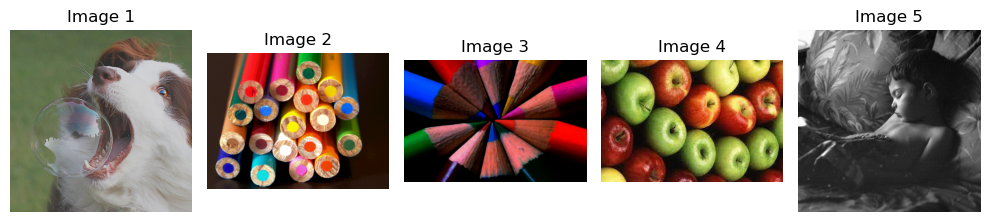

In [3]:
# ~~~~~ Display Original Images
i = 0

# Set up the plot
plt.figure(figsize=(10, 5))

# 1 row and 5 columns
for i,img in enumerate(images):
    plt.subplot(1,5, i+1)

    # If image is grayscale, apply grayscale color map
    if img.ndim == 2:
        plt.imshow(img, cmap = "gray")
    else:
        plt.imshow(img)
    
    plt.axis('off')
    plt.title(f"Image {i+1}")
    
# Show the plot
plt.tight_layout()
plt.show()

In [4]:
# ~~~~~ Function to convert an image to grayscale by applying a Transformation formula

def rgb_to_grayscale(img):
    # Check if the image has three dimensions (RGB)
    if img.ndim == 3:  
        Zr = img[:, :, 0]  # red channel
        Zg = img[:, :, 1]  # green channel
        Zb = img[:, :, 2]  # blue channel
        
        # Apply the grayscale transformation formula
        grayscale_img = 0.3 * Zr + 0.6 * Zg + 0.1 * Zb
    else:
        # If the image is already grayscale, use it directly
        grayscale_img = img
    
    return grayscale_img


In [5]:
# ~~~~~ Convert all images to grayscale

# Initialize an empty list to store the grayscale images
grayscale_img = []

# Store all the converted grayscale images into an array
for img in images:
    grayscale_img.append(rgb_to_grayscale(img))

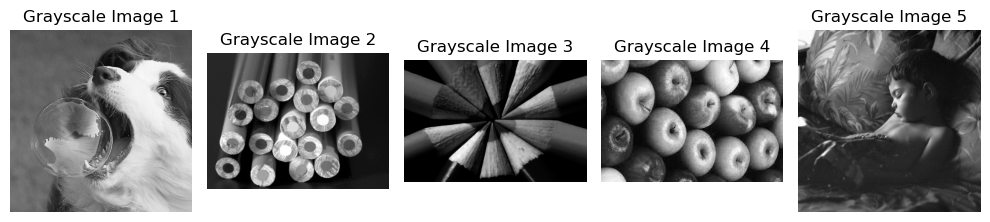

In [6]:
# ~~~~~ Display Grayscale Images
i = 0

# Set up the plot
plt.figure(figsize=(10, 5))

# 1 row and 5 columns
for i,img in enumerate(grayscale_img):
    plt.subplot(1,5, i+1)
    plt.imshow(img, cmap = "gray")    
    plt.axis('off')
    plt.title(f"Grayscale Image {i+1}")
    
# Show the plot
plt.tight_layout()
plt.show()

In [7]:
# ~~~~~ Custom function that calculates the Histogram of each grayscale image
# Initialize an array of zeros to store the histogram counts. The size of the array is equal to the # of bins
# For easier iteration flatten the 2D image array into a 1D array
# Increment the histogram at the index corresponding to the pixel value
# Return both the histogram counts and the bin edges
#  -histogram tells us how many pixels there are for each intensity.
#  -bin_edges shows the range of each intensity bin 

def custom_histogram(image, bins=256):
    histogram = np.zeros(bins, dtype=int)
    
    for pixel_value in image.ravel():
        histogram[int(pixel_value)] += 1
        
    bin_edges = np.arange(bins + 1)
    
    return histogram, bin_edges

In [8]:
# ~~~~~ Function to display an image and its histogram

def display_my_histogram(image, title="Image"):
    plt.figure(figsize=(10, 5))
    
    # Display the grayscale image
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.title(title)
    
    # Calculate and display the histogram
    histogram, bin_edges = custom_histogram(image, bins = 256)
    plt.subplot(1, 2, 2)
    plt.plot(bin_edges[:-1], histogram, label="Histogram")
    plt.title("Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

    # 1. Otsu's method
    from skimage.filters import threshold_otsu
    threshold_otsu_value = threshold_otsu(image)
    print(f"Otsu's threshold: {threshold_otsu_value}")

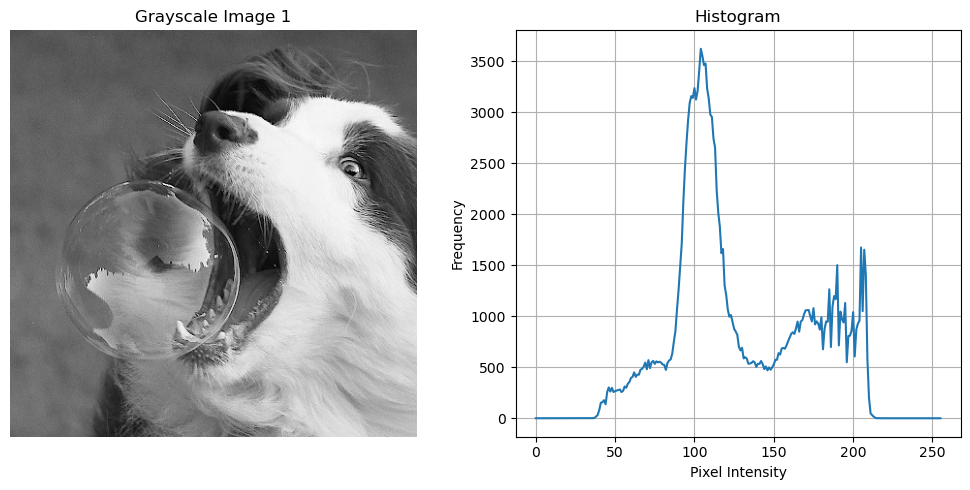

Otsu's threshold: 139.72617187499998


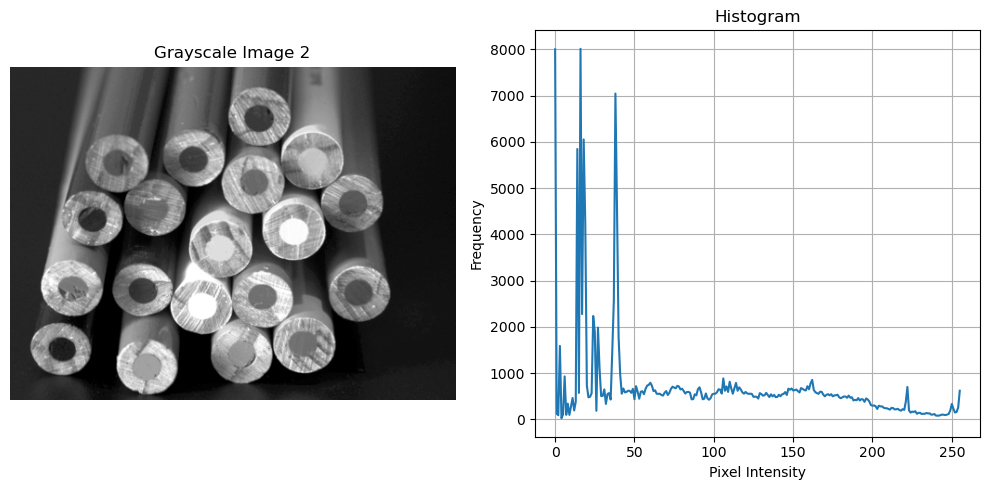

Otsu's threshold: 98.115234375


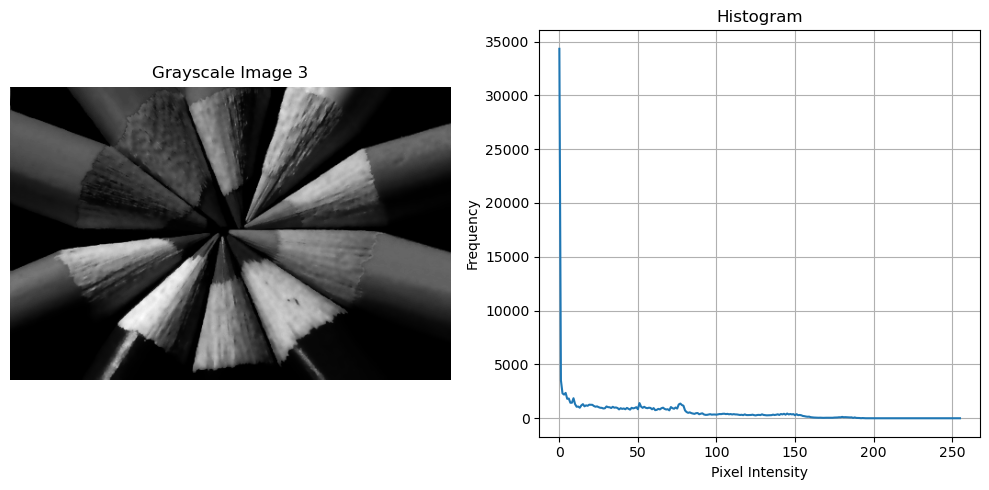

Otsu's threshold: 58.028515625


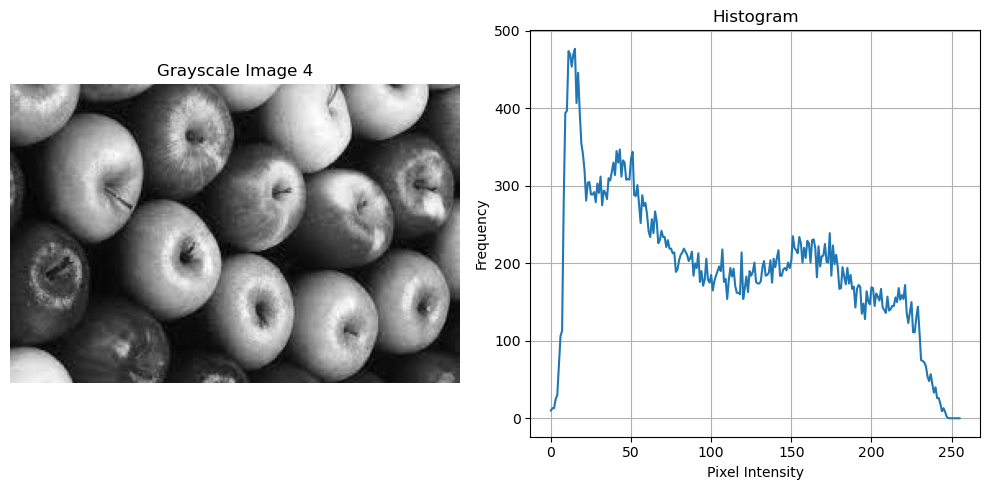

Otsu's threshold: 110.07578124999999


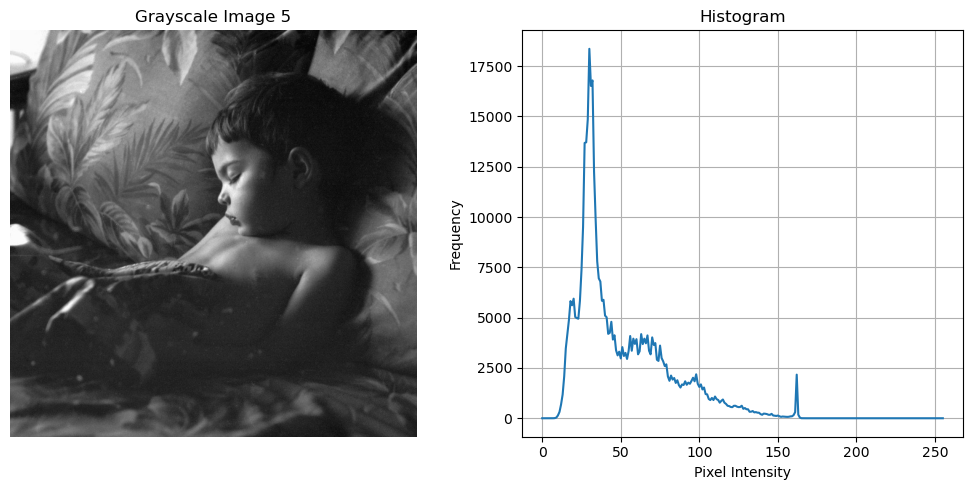

Otsu's threshold: 61


In [9]:
# Loop through the list of grayscale images and apply the display function
for i, image in enumerate(grayscale_img):
    display_my_histogram(image, title=f"Grayscale Image {i+1}")

In [10]:
# ~~~~~ Custom function to convert grayscale image to binary image
# Apply threshold: if the pixel intensity is greater than the threshold, set it to 255, otherwise set it to 0
# Pixels brighter than this threshold become white (255), and pixels darker than this threshold become black (0).
# Return binary image. A 2D array where each pixel is either 0 or 255.

def convert_to_binary(image, threshold):
    binary_image = np.where(image > threshold, 255, 0).astype(np.uint8)
    
    return binary_image

In [11]:
# ~~~~~ Display the original grayscale and the generated binary images side by side,with titles showing the threshold values.
# I will make it as a function because i want to use it for all my images

def display_binary_img(grayscale_img, thresholds, binary_images):
    # Ensure inputs are valid
    if len(binary_images) != len(thresholds):
        print("The number of binary images must match the number of thresholds.")
        return

    # Set up the plot
    plt.figure(figsize=(30, 15))

    # Display the grayscale image
    plt.subplot(1, len(binary_images) + 1, 1)
    plt.imshow(grayscale_img, cmap='gray')
    plt.axis('off')
    plt.title("Grayscale Image")
    
    # Display each binary image with its threshold value
    for i, (binary_image, th) in enumerate(zip(binary_images, thresholds), start=2):
        plt.subplot(1, len(binary_images) + 1, i)
        plt.imshow(binary_image, cmap='gray')
        plt.axis('off')
        title = f"Binary Img with Th = {th}"
        plt.title(title)
    
    # Adjust layout and save the figure
    plt.tight_layout()
    plt.show()

In [12]:
# Function to calculate pixel count for binary images
# Analyzes the distribution of white and black pixels for a list of binary images  generated using different threshold values.
def pixel_count_analysis(binary_images, thresholds):
    results = []
    for binary_image, threshold in zip(binary_images, thresholds):
        white_pixels = np.sum(binary_image == 255)
        black_pixels = np.sum(binary_image == 0)
        total_pixels = binary_image.size
        results.append({
            "Threshold": threshold,
            "White Pixels": white_pixels,
            "Black Pixels": black_pixels,
            "Total Pixels": total_pixels
        })
    return results

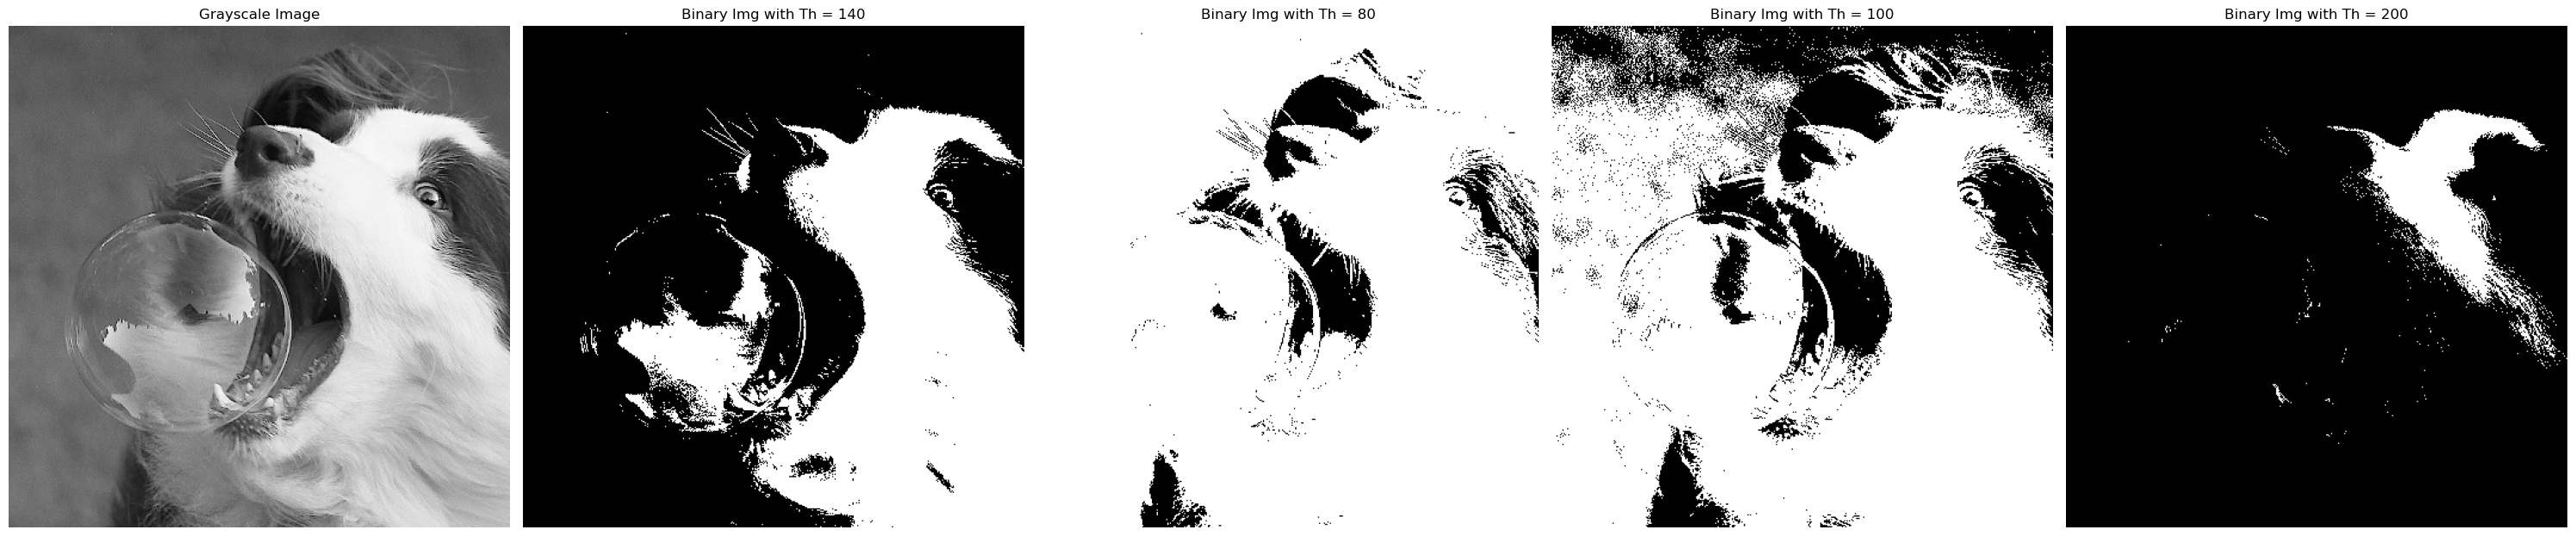

[{'Threshold': 140,
  'White Pixels': 60491,
  'Black Pixels': 115909,
  'Total Pixels': 176400},
 {'Threshold': 80,
  'White Pixels': 161364,
  'Black Pixels': 15036,
  'Total Pixels': 176400},
 {'Threshold': 100,
  'White Pixels': 130828,
  'Black Pixels': 45572,
  'Total Pixels': 176400},
 {'Threshold': 200,
  'White Pixels': 10844,
  'Black Pixels': 165556,
  'Total Pixels': 176400}]

In [84]:
# ~~~~~ I will determine the main threshold manually based from the histogram and then for experimental reasons i will choose
# at least two additional threshold values (higher and lower than my initial choice) to generate different results

# ~~~ Working for image 1 ~~~
# By observing the histogram of the 1st image
# To experiment with different thresholds, from the histogram we will choose each time the peaks (peak to peak) and then get a value in between them.

# Set main threshold
threshold_1 = 140

# Set lower, middle and higher thresholds.
lower_th = 80
middle_th = 100
higher_th = 200

# save thresholds on array
thresholds = [threshold_1, lower_th, middle_th, higher_th]

# Create a list to store the binary images
binary_images = []

# Loop through the thresholds and apply the corresponding conversion
for i in range(len(thresholds)):
    # Apply the threshold and convert the image to binary
    binary_image = convert_to_binary(grayscale_img[0], thresholds[i])
    
    # Append the processed image to the list
    binary_images.append(binary_image)


# Display the original grayscale and binary images side by side
display_binary_img(grayscale_img[0], thresholds, binary_images)

# For each binary image generated, count and report the number of white and black pixels
pixel_count_analysis(binary_images, thresholds)

In [ ]:
# At lower thresholds, such as 40, almost all pixel intensities are above the threshold, which is why the resulting binary image is overwhelmingly white, including details that should belong to the darker background.
# As the threshold increases, for example to 80 or 100, the background and shadowed areas, represented by lower intensities,
# are effectively excluded, leaving only the mid-range and high-intensity regions that correspond to the main subject.
# This aligns with the histogram’s peak at around 100, confirming that the segmentation at this threshold is correctly isolating the subject. At higher thresholds, such as 200, only the brightest areas remain white,
# which corresponds to the smaller peak in the histogram near the highest intensities.

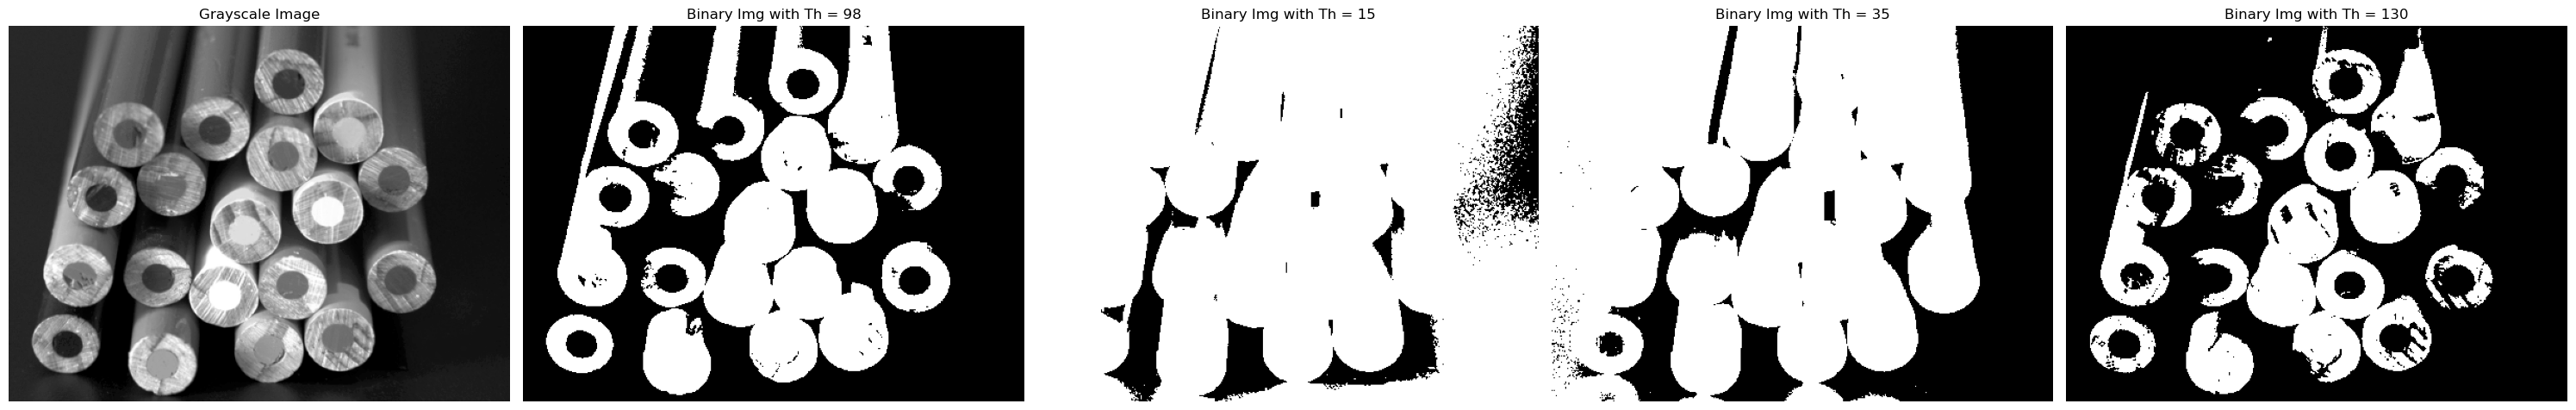

[{'Threshold': 98,
  'White Pixels': 68167,
  'Black Pixels': 104633,
  'Total Pixels': 172800},
 {'Threshold': 15,
  'White Pixels': 154140,
  'Black Pixels': 18660,
  'Total Pixels': 172800},
 {'Threshold': 35,
  'White Pixels': 120290,
  'Black Pixels': 52510,
  'Total Pixels': 172800},
 {'Threshold': 130,
  'White Pixels': 48899,
  'Black Pixels': 123901,
  'Total Pixels': 172800}]

In [80]:
# ~~~ Working for image 2 ~~~
# By observing the histogram of the 2nd image
# To experiment with different thresholds, from the histogram we will choose each time the peaks (peak to peak) and then get a value in between them.

# Set main threshold
threshold_2 = 98

# Set lower, middle and higher thresholds.
lower_th = 15
middle_th = 35
higher_th = 130

# save thresholds on array
thresholds = [threshold_2, lower_th, middle_th, higher_th]

# Create a list to store the binary images
binary_images = []

# Loop through the thresholds and apply the corresponding conversion
for i in range(len(thresholds)):
    # Apply the threshold and convert the image to binary
    binary_image = convert_to_binary(grayscale_img[1], thresholds[i])
    
    # Append the processed image to the list
    binary_images.append(binary_image)


# Display the original grayscale and binary images side by side
display_binary_img(grayscale_img[1], thresholds, binary_images)

# For each binary image generated, count and report the number of white and black pixels
pixel_count_analysis(binary_images, thresholds)

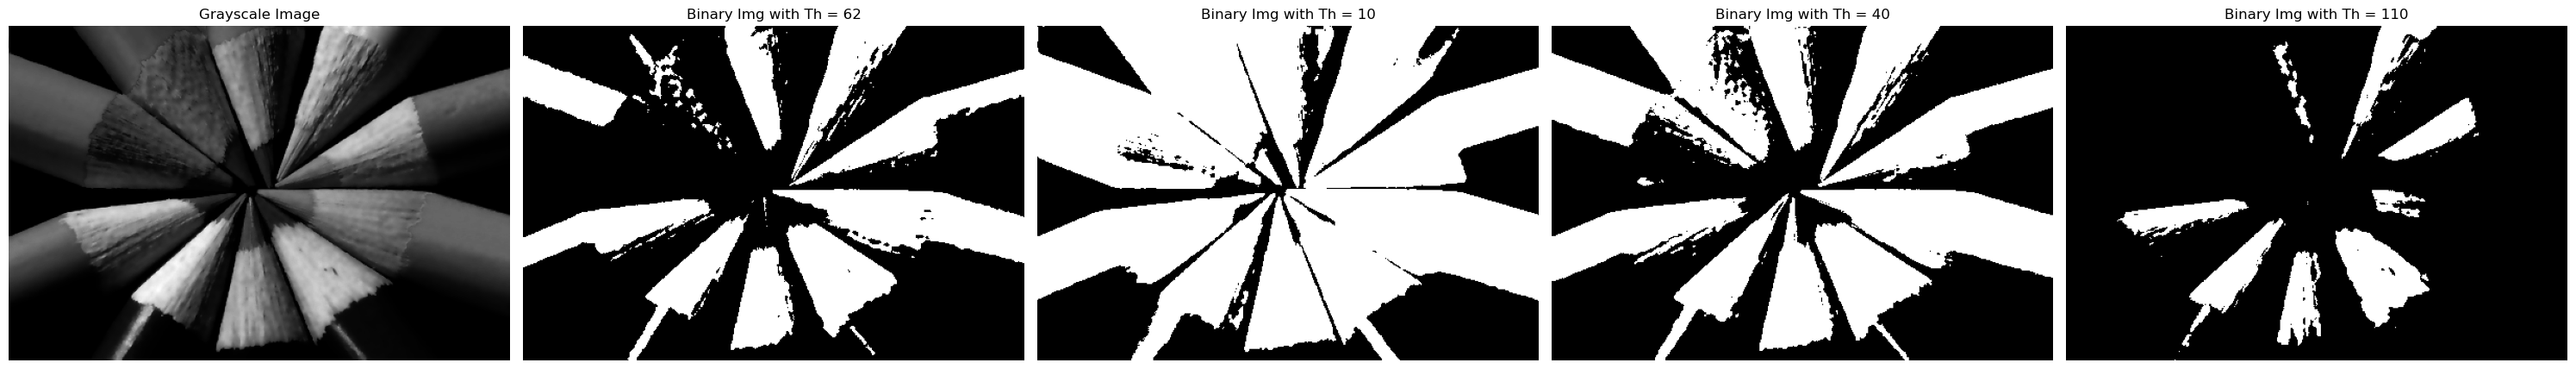

[{'Threshold': 62,
  'White Pixels': 47470,
  'Black Pixels': 106130,
  'Total Pixels': 153600},
 {'Threshold': 10,
  'White Pixels': 100447,
  'Black Pixels': 53153,
  'Total Pixels': 153600},
 {'Threshold': 40,
  'White Pixels': 68304,
  'Black Pixels': 85296,
  'Total Pixels': 153600},
 {'Threshold': 110,
  'White Pixels': 17603,
  'Black Pixels': 135997,
  'Total Pixels': 153600}]

In [75]:
# ~~~ Working for image 3 ~~~
# By observing the histogram of the 3rd image
# To experiment with different thresholds, from the histogram we will choose each time the peaks (peak to peak) and then get a value in between them.
# Set main threshold
threshold_3 = 62

# Set lower, middle and higher thresholds.
lower_th = 10
middle_th = 40
higher_th = 110

# save thresholds on array
thresholds = [threshold_3, lower_th, middle_th, higher_th]

# Create a list to store the binary images
binary_images = []

# Loop through the thresholds and apply the corresponding conversion
for i in range(len(thresholds)):
    # Apply the threshold and convert the image to binary
    binary_image = convert_to_binary(grayscale_img[2], thresholds[i])
    
    # Append the processed image to the list
    binary_images.append(binary_image)


# Display the original grayscale and binary images side by side
display_binary_img(grayscale_img[2], thresholds, binary_images)

# For each binary image generated, count and report the number of white and black pixels
pixel_count_analysis(binary_images, thresholds)

In [44]:
# The histogram has a large peak near intensity 0, indicating that a significant portion of the image is dark.

# The ideal threshold is where we separate the dark background from the lighter pencil tips.
# The threshold should be chosen near the point where the dark peak transitions into the mid-range values.

# The lower threshold will highlight only the brightest area -perhaps only the tips-.

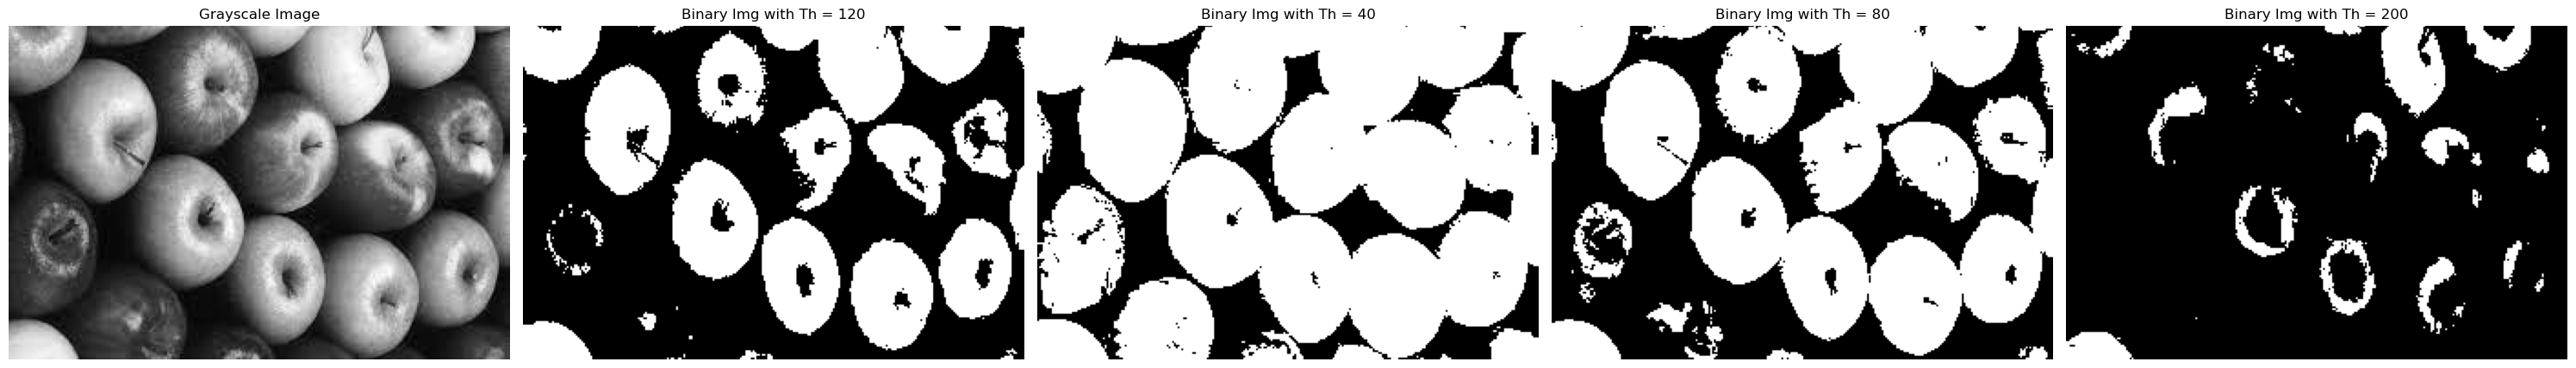

In [45]:
# ~~~ Working for image 4 ~~~
# By observing the histogram of the 4th image
# To experiment with different thresholds, from the histogram we will choose each time the peaks (peak to peak) and then get a value in between them.

# Set main threshold
threshold_4 = 120

# Set lower, middle and higher thresholds.
lower_th = 40
middle_th = 80
higher_th = 200

# save thresholds on array
thresholds = [threshold_4, lower_th, middle_th, higher_th]

# Create a list to store the binary images
binary_images = []

# Loop through the thresholds and apply the corresponding conversion
for i in range(len(thresholds)):
    # Apply the threshold and convert the image to binary
    binary_image = convert_to_binary(grayscale_img[3], thresholds[i])
    
    # Append the processed image to the list
    binary_images.append(binary_image)


# Display the original grayscale and binary images side by side
display_binary_img(grayscale_img[3], thresholds, binary_images)

# For each binary image generated, count and report the number of white and black pixels
pixel_count_analysis(binary_images, thresholds)

In [40]:
# From the histogram in the image 4, the large peak near 0 suggests that many pixels are dark,
# likely representing shadows or dark portions of the apples. 

# The ideal threshold typically separates the foreground (apples) from the background (darker or lighter regions).
# Looking at the histogram, the pixel intensity values are concentrated at lower intensities (0–50) and then taper off.
# A noticeable drop occurs near the mid-range intensities (around 100–150), which suggests this could be an appropriate threshold range to experiment with for binary segmentation.

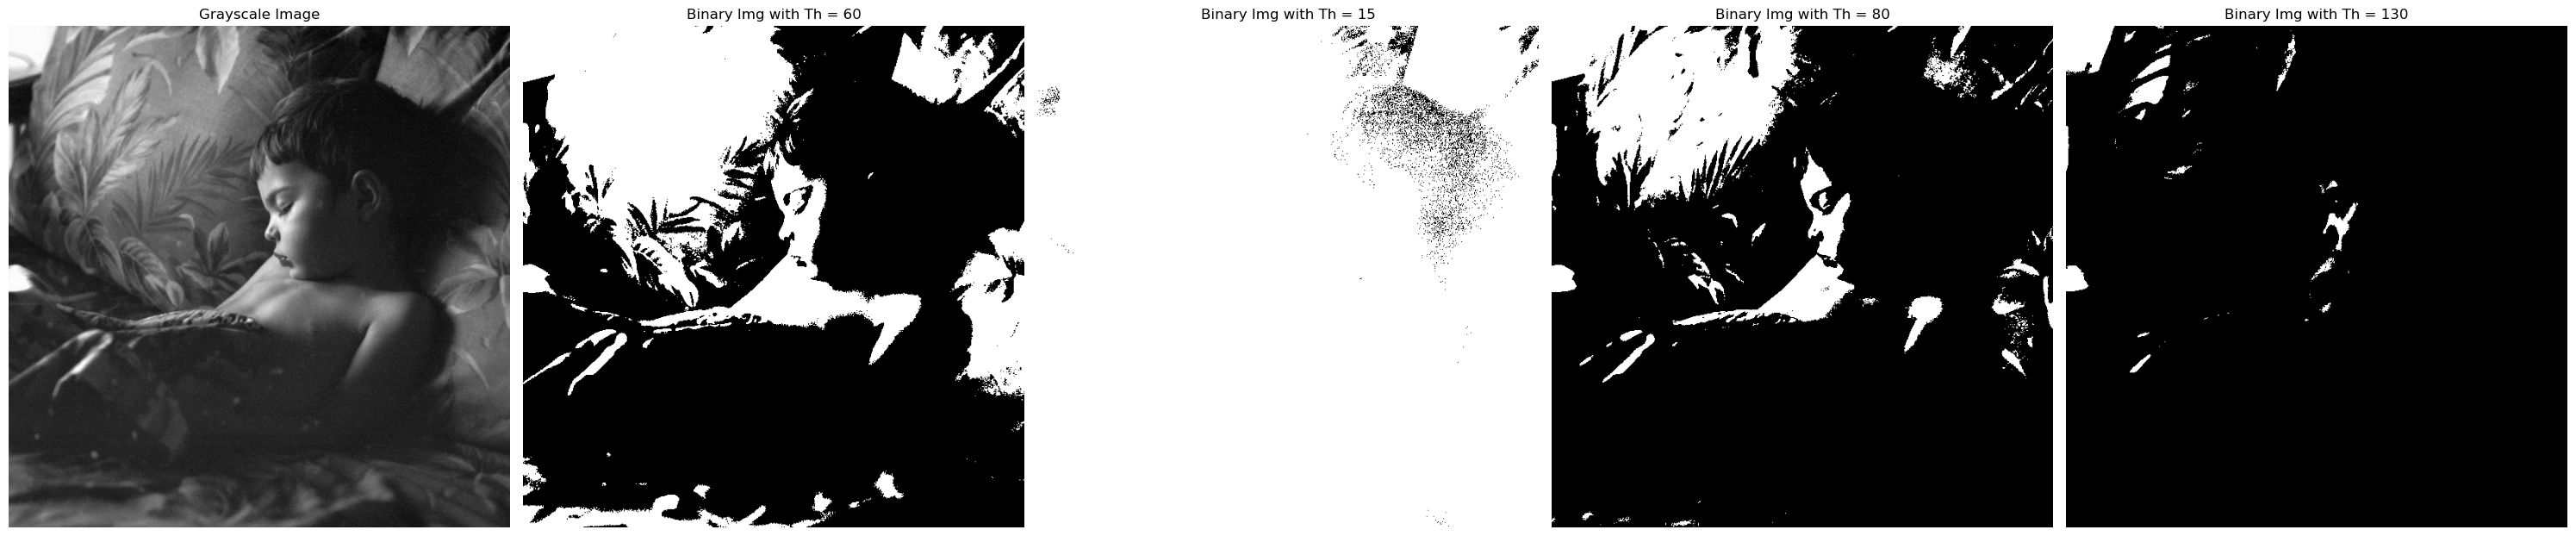

[{'Threshold': 60,
  'White Pixels': 136238,
  'Black Pixels': 300683,
  'Total Pixels': 436921},
 {'Threshold': 15,
  'White Pixels': 429004,
  'Black Pixels': 7917,
  'Total Pixels': 436921},
 {'Threshold': 80,
  'White Pixels': 69602,
  'Black Pixels': 367319,
  'Total Pixels': 436921},
 {'Threshold': 130,
  'White Pixels': 8295,
  'Black Pixels': 428626,
  'Total Pixels': 436921}]

In [68]:
# ~~~~~ I will determine the main threshold manually based from the histogram and then for experimental reasons i will choose
# at least two additional threshold values (higher and lower than my initial choice) to generate different results

# ~~~ Working for image 5 ~~~
# By observing the histogram of the fifth image, the main threshold should be around pixel intensity 50, because there i can observe a sudden "drop".
# This may suggest a good threshold for seperating the light and dark regions of the image
# To experiment with different thresholds, from the histogram we will choose each time the peaks (peak to peak) and then get a value in between them.

# Set main threshold
threshold_5 = 60

# Set lower, middle and higher thresholds.
lower_th = 15
middle_th = 80
higher_th = 130

# save thresholds on array
thresholds = [threshold_5, lower_th, middle_th, higher_th]

# Create a list to store the binary images
binary_images = []

# Loop through the thresholds and apply the corresponding conversion
for i in range(len(thresholds)):
    # Apply the threshold and convert the image to binary
    binary_image = convert_to_binary(grayscale_img[4], thresholds[i])
    
    # Append the processed image to the list
    binary_images.append(binary_image)

# Display the original grayscale and generated binary images side by side
display_binary_img(grayscale_img[4], thresholds, binary_images)

# For each binary image generated, count and report the number of white and black pixels
pixel_count_analysis(binary_images, thresholds)

In [43]:
# The output shows how different threshold values affect the binarization of a grayscale image. 
# In the region where the threshold is "15" we can observe that the number of pixels in the lower intensities ( image < 15) are much lower than the number of pixels after th=15 (image > 15),
# where after th=15 we can see a drastical ascent of them. Pixels with an intensity close to zero are very close to black. Therefore, due to the small # of pixels around that intensity,
# that explains why the image with th=15 is so bright and noisy.

# As the threshold value increases, the binary image becomes less noisy and more defined.
# The background becomes more uniform, and the foreground details become clearer. 
# On the other hand, now for the higher threshold th=130, with pixel intensity close to 255, the number of pixels is close to zero.
# That means that there are almost no white pixels. This is confirmed by the produced image.

# In summary, The peak around 30-40 suggests that there are a lot of pixels with that intensity, which likely corresponds to the dark areas of the image.
# This is confirmed by the image itself, which appears to be mostly dark with a bright child in the middle. 
# The sharp increase in the histogram at 170 is likely due to the bright areas of the child.


In [86]:
# Pixel count
# As the threshold value changes, the distribution of pixels in the binary images is significantly impacted, as seen in the provided analysis.
# As an example i will have image 1.:
# At lower thresholds, such as 80, a majority of the pixels are classified as "white," with 161,364 pixels marked as white and only 15,036 as black. This occurs because a low threshold allows a wider range of pixel intensities to pass the threshold, including many darker regions that may belong to the background or shadows. 
# As the threshold increases to 100, the number of white pixels decreases to 130,828, while black pixels increase to 45,572. This reflects a shift where more of the darker regions are now excluded, focusing the segmentation on lighter parts of the subject.

# In general, by observing the changing of the number of pixels we can completely understand how thresholding affects the pixel majority and why thresholding is so important.